In [3]:
import numpy as np 
import pandas as pd 
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D
from sklearn.datasets import load_breast_cancer


In [4]:
df=pd.read_csv(r"C:\Users\YASHVIR\Downloads\Pass-Fail Data.csv")

In [5]:
df[:2]

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,95,92,88,12,1
1,2,88,85,79,10,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   student_id            100 non-null    int64
 1   attendance_pct        100 non-null    int64
 2   homework_pct          100 non-null    int64
 3   midterm_score         100 non-null    int64
 4   study_hours_per_week  100 non-null    int64
 5   pass                  100 non-null    int64
dtypes: int64(6)
memory usage: 4.8 KB


In [7]:
df.shape

(100, 6)

In [8]:
correlation=df.corr()["pass"].sort_values(ascending=False)
print(correlation)

pass                    1.000000
attendance_pct          0.873757
homework_pct            0.869662
midterm_score           0.839442
study_hours_per_week    0.811285
student_id             -0.036771
Name: pass, dtype: float64


In [9]:
X=df.drop(["pass"],axis=1)
y=df["pass"]

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
scaler=StandardScaler( )
X_train_Scaled=scaler.fit_transform(X_train)
X_test_Scaled=scaler.transform(X_test)

In [13]:
df["pass"].value_counts()

pass
1    60
0    40
Name: count, dtype: int64

In [14]:
#  the value counts are balanced do no need for SMOTE
# we directly train the model on this dataset

In [15]:
print("Number of Features=",X_train_Scaled.shape[1])

Number of Features= 5


In [16]:
model=Sequential()
model.add(Dense(32,activation="relu",input_shape=(X_train_Scaled.shape[1],)
                ))
model.add(Dense(16,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

C:\Users\YASHVIR\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(
    optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"]
)

In [18]:
history=model.fit(X_train_Scaled,y_train,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - accuracy: 0.8281 - loss: 0.6312 - val_accuracy: 1.0000 - val_loss: 0.6028
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9062 - loss: 0.6062 - val_accuracy: 1.0000 - val_loss: 0.5729
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9062 - loss: 0.5841 - val_accuracy: 1.0000 - val_loss: 0.5439
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9062 - loss: 0.5617 - val_accuracy: 1.0000 - val_loss: 0.5157
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9062 - loss: 0.5400 - val_accuracy: 1.0000 - val_loss: 0.4889
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9062 - loss: 0.5194 - val_accuracy: 1.0000 - val_loss: 0.4633
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9062 - loss: 0.5008 - val_accuracy: 1.0000 - val_loss: 0.4388
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9062 - loss: 0.4816 - val_accuracy: 1.0000 - val_loss: 0.4155

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,213 (8.65 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,476 (5.77 KB)

In [20]:
# now the prediction of ANN is tp be made 
y_pred=model.predict(X_test_Scaled)
y_pred=(y_pred > 0.5).astype(int)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


In [21]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [22]:
# calculating the accuracy of the ANN
ann_acc=accuracy_score(y_test,y_pred)
print("ANN accuracy_score",ann_acc)

ANN accuracy_score 0.95


In [23]:
print(confusion_matrix(y_test,y_pred))

[[ 8  0]
 [ 1 11]]


In [24]:
# now the model CNN


In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.layers import Dropout


In [26]:
(X_trainc,y_trainc),(X_testc,y_testc)=tf.keras.datasets.mnist.load_data()


In [27]:
print("Training images shape:",X_trainc.shape)
print("Training Labels Shape:",y_trainc.shape)

print("Testing images Shape:",X_testc.shape)
print("Testing Labels Shape:",y_testc.shape)

Training images shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Testing images Shape: (10000, 28, 28)
Testing Labels Shape: (10000,)


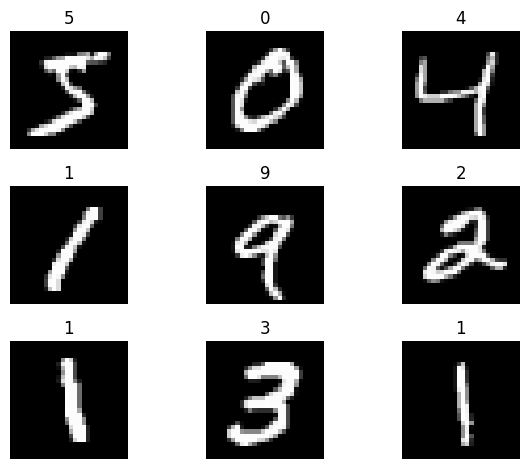

In [28]:
import matplotlib.pyplot as plt 
for i in range (9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_trainc[i],cmap='gray')
    plt.title(y_trainc[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [29]:
X_trainc=X_trainc/255.0
X_testc=X_testc/255.0

In [30]:
X_trainc=X_trainc.reshape(-1,28,28,1)
X_testc=X_testc.reshape(-1,28,28,1)


In [31]:
from tensorflow.keras.utils import to_categorical

one hot encoding 

In [32]:
y_trainc=to_categorical(y_trainc,10)
y_testc=to_categorical(y_testc,10)

In [33]:
model=Sequential()

In [34]:
model.add(Conv2D(32,(3,3),activation="relu",input_shape=(28,28,1)))
model.add( MaxPooling2D(pool_size=(2,2)))

C:\Users\YASHVIR\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model.add(Flatten())

In [36]:
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))

In [37]:
model.add(Dense(10,activation='softmax'))

In [38]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
history= model.fit(
    X_trainc,
    y_trainc,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8795 - loss: 0.3924 - val_accuracy: 0.9717 - val_loss: 0.0970
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9485 - loss: 0.1726 - val_accuracy: 0.9763 - val_loss: 0.0800
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9596 - loss: 0.1371 - val_accuracy: 0.9812 - val_loss: 0.0654
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9648 - loss: 0.1170 - val_accuracy: 0.9826 - val_loss: 0.0598
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9696 - loss: 0.0996 - val_accuracy: 0.9837 - val_loss: 0.0561
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9716 - loss: 0.0915 - val_accuracy: 0.9847 - val_loss: 0.0553
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9737 - loss: 0.0852 - val_accuracy: 0.9843 - val_loss: 0.0544
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9755 - loss: 0.0772

In [41]:
loss,accuracy=model.evaluate(X_testc,y_testc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9873 - loss: 0.0448


In [42]:
y_predc=(model.predict(X_testc) >0.5).astype(int)
cnn_acc=accuracy_score(y_testc,y_predc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [43]:
print("CNN ACCURACY:",cnn_acc)

CNN ACCURACY: 0.9868
